# Clustering de complejidad de trámites (no supervisado)

Este notebook construye un **análisis de clustering** para segmentar trámites por complejidad de forma exploratoria.

## Objetivo
- Descubrir grupos naturales de trámites.
- Apoyar la interpretación con gráficas.
- Generar insumos para definir etiquetas iniciales de complejidad (`Baja`, `Media`, `Alta`) en una etapa supervisada posterior.


## Variables de clustering

Se usan variables de carga administrativa e interacción digital:
- `log_tiempo` (log de `Tiempo_en_minutos`)
- `CONTEO_NETO`
- `N_FORMATOS_FINAL`
- `nivel_digitalizacion` codificado como categoría (incluye `Sin_nivel`)

> Nota: este clustering es exploratorio y **no implica causalidad**.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
RANDOM_STATE = 42

In [2]:
# Carga de datos
root = Path.cwd().parent

df = pd.read_csv(root / 'Effor_index_MASTER.csv').dropna(subset=['Idtram']).copy()

print('Filas/columnas:', df.shape)
print(df[['Tiempo_en_minutos','CONTEO_NETO','N_FORMATOS_FINAL','nivel_digitalizacion']].head(3))

Filas/columnas: (665, 14)
   Tiempo_en_minutos  CONTEO_NETO  N_FORMATOS_FINAL nivel_digitalizacion
0                5.0            1                 0              Nivel 1
1               10.0            8                 2            Nivel 4.1
2               20.0           10                 3                  NaN


In [3]:
# Utilidades para nivel de digitalización
def parse_level_num(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r'([0-9]+(?:\.[0-9]+)?)', str(x))
    return float(m.group(1)) if m else np.nan

def format_level(level_num):
    if pd.isna(level_num):
        return np.nan
    if float(level_num).is_integer():
        return f'Nivel {int(level_num)}'
    return f'Nivel {level_num:.1f}'

In [4]:
# Preprocesamiento
df['nivel_num'] = df['nivel_digitalizacion'].map(parse_level_num)
df['nivel_label'] = df['nivel_num'].map(format_level)
df['nivel_cat'] = df['nivel_label'].fillna('Sin_nivel')

df['Tiempo_en_minutos'] = df['Tiempo_en_minutos'].fillna(df['Tiempo_en_minutos'].median())
df['CONTEO_NETO'] = df['CONTEO_NETO'].fillna(df['CONTEO_NETO'].median())
df['N_FORMATOS_FINAL'] = df['N_FORMATOS_FINAL'].fillna(df['N_FORMATOS_FINAL'].median())

df['log_tiempo'] = np.log1p(df['Tiempo_en_minutos'].clip(lower=0))

print('Nulos totales en variables base:', int(df[['log_tiempo','CONTEO_NETO','N_FORMATOS_FINAL','nivel_cat']].isna().sum().sum()))
print(df['nivel_cat'].value_counts().head(10))

Nulos totales en variables base: 0
nivel_cat
Nivel 1      262
Sin_nivel    209
Nivel 2       70
Nivel 3.5     41
Nivel 3.7     24
Nivel 4.1     18
Nivel 3.1     14
Nivel 3.9     10
Nivel 4.3      7
Nivel 4.2      6
Name: count, dtype: int64


In [5]:
# Matriz de características para clustering
num_features = ['log_tiempo', 'CONTEO_NETO', 'N_FORMATOS_FINAL']
cat_dummies = pd.get_dummies(df['nivel_cat'], prefix='nivel', drop_first=False)

X = pd.concat([df[num_features], cat_dummies], axis=1)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Dimensión matriz X:', X.shape)
print('Primeras columnas:', feature_names[:8])

Dimensión matriz X: (665, 15)
Primeras columnas: ['log_tiempo', 'CONTEO_NETO', 'N_FORMATOS_FINAL', 'nivel_Nivel 1', 'nivel_Nivel 2', 'nivel_Nivel 3.1', 'nivel_Nivel 3.2', 'nivel_Nivel 3.5']


In [6]:
# Selección de k: elbow + silhouette
k_range = range(2, 9)
rows = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_scaled, labels)
    })

k_eval = pd.DataFrame(rows)
best_k = int(k_eval.loc[k_eval['silhouette'].idxmax(), 'k'])

print('Mejor k por silhouette:', best_k)
k_eval

Mejor k por silhouette: 8


,k,inertia,silhouette
0,2,8977.445225,0.211539
1,3,8195.168289,0.242297
2,4,7389.707383,0.323831
3,5,6683.460893,0.346245
4,6,6022.824051,0.361133
5,7,5281.115589,0.432216
6,8,4600.593088,0.450228


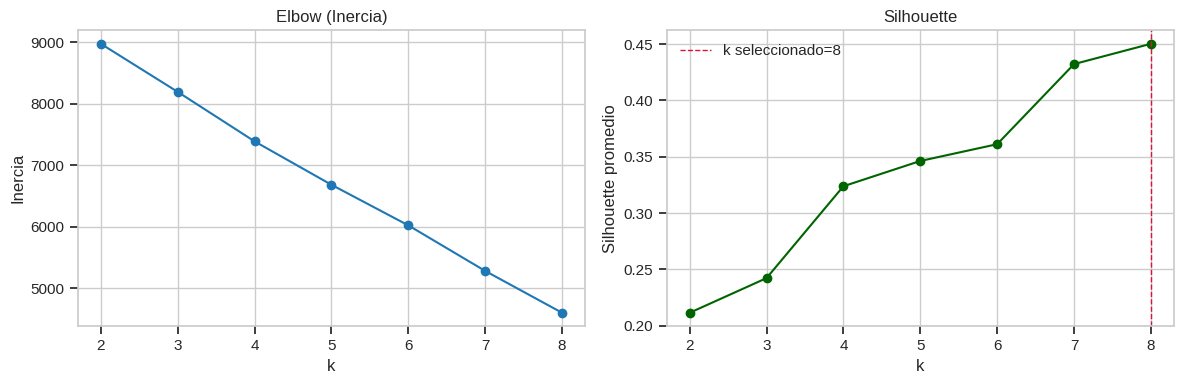

In [7]:
# Gráfico de apoyo para seleccionar k
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_eval['k'], k_eval['inertia'], marker='o')
axes[0].set_title('Elbow (Inercia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')

axes[1].plot(k_eval['k'], k_eval['silhouette'], marker='o', color='darkgreen')
axes[1].axvline(best_k, color='crimson', linestyle='--', linewidth=1, label=f'k seleccionado={best_k}')
axes[1].set_title('Silhouette')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette promedio')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Entrenamiento final de clustering
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster'])
print('Silhouette final:', round(float(sil_final), 4))
print(df['cluster'].value_counts().sort_index())

Silhouette final: 0.4502
cluster
0    275
1     17
2     10
3     71
4     41
5     24
6    209
7     18
Name: count, dtype: int64


/tmp/ipykernel_106601/3966594693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_size, x='cluster', y='n', palette='Set2', ax=ax)


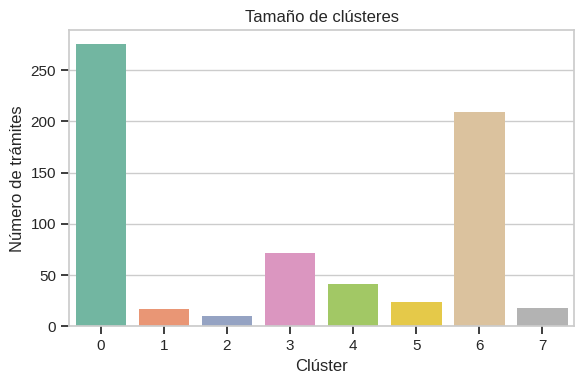

,cluster,n
0,0,275
1,1,17
2,2,10
3,3,71
4,4,41
5,5,24
6,6,209
7,7,18


In [9]:
# Tamaño de clústeres
cluster_size = df['cluster'].value_counts().sort_index().rename_axis('cluster').reset_index(name='n')

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=cluster_size, x='cluster', y='n', palette='Set2', ax=ax)
ax.set_title('Tamaño de clústeres')
ax.set_xlabel('Clúster')
ax.set_ylabel('Número de trámites')
plt.tight_layout()
plt.show()

cluster_size

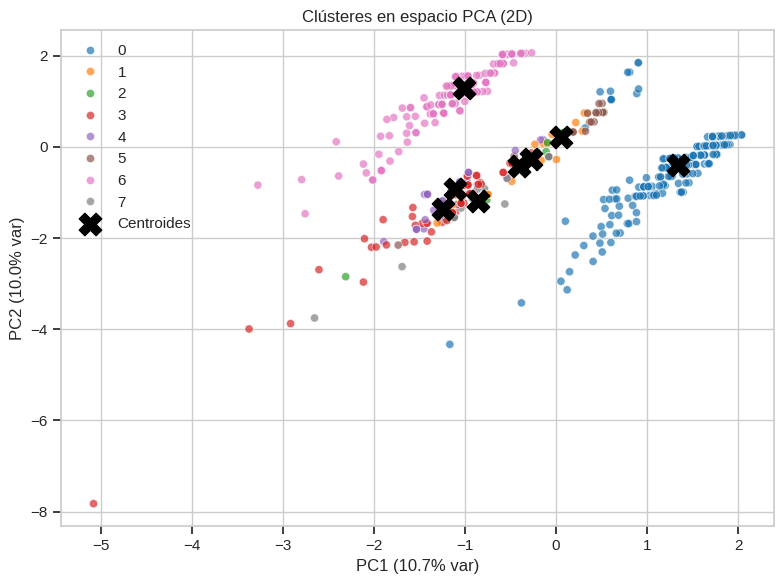

In [10]:
# Proyección PCA a 2D para visualización
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

viz = pd.DataFrame({'pc1': coords[:,0], 'pc2': coords[:,1], 'cluster': df['cluster']})
centers_2d = pca.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=viz, x='pc1', y='pc2', hue='cluster', palette='tab10', alpha=0.7, s=35, ax=ax)
ax.scatter(centers_2d[:,0], centers_2d[:,1], marker='X', s=260, c='black', label='Centroides')
ax.set_title('Clústeres en espacio PCA (2D)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Perfil descriptivo por clúster
def mode_or_nan(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

df['TraCosto_bin'] = (df['TraCosto'].astype(str).str.upper() == 'VERDADERO').astype(int)

cluster_profile = (
    df.groupby('cluster', as_index=False)
      .agg(
          n=('Idtram', 'size'),
          med_tiempo=('Tiempo_en_minutos', 'median'),
          med_log_tiempo=('log_tiempo', 'median'),
          med_requisitos=('CONTEO_NETO', 'median'),
          med_formatos=('N_FORMATOS_FINAL', 'median'),
          pct_costo=('TraCosto_bin', 'mean'),
          nivel_moda=('nivel_cat', mode_or_nan)
      )
      .sort_values('cluster')
)

cluster_profile['pct_costo'] = (cluster_profile['pct_costo'] * 100).round(2)
cluster_profile

,cluster,n,med_tiempo,med_log_tiempo,med_requisitos,med_formatos,pct_costo,nivel_moda
0,0,275,1440.0,7.273093,1.0,0.0,72.00,Nivel 1
1,1,17,1440.0,7.273093,2.0,1.0,52.94,Nivel 3.1
2,2,10,1440.0,7.273093,2.5,0.0,100.00,Nivel 3.9
3,3,71,1440.0,7.273093,2.0,1.0,57.75,Nivel 2
4,4,41,21600.0,9.980495,2.0,1.0,97.56,Nivel 3.5
5,5,24,330.0,5.687182,2.0,0.0,100.00,Nivel 3.7
6,6,209,1440.0,7.273093,1.0,1.0,62.20,Sin_nivel
7,7,18,3600.0,7.965979,3.0,1.0,72.22,Nivel 4.1


/tmp/ipykernel_106601/1892708607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='log_tiempo', ax=axes[0], palette='Set3')
/tmp/ipykernel_106601/1892708607.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='CONTEO_NETO', ax=axes[1], palette='Set3')
/tmp/ipykernel_106601/1892708607.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='N_FORMATOS_FINAL', ax=axes[2], palette='Set3')


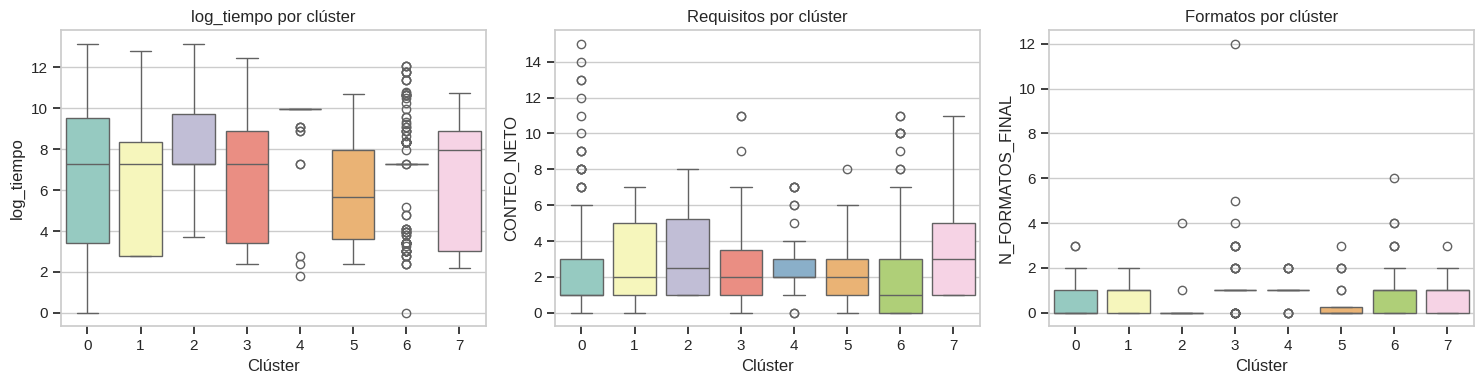

In [12]:
# Boxplots para interpretación de complejidad intrínseca
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='cluster', y='log_tiempo', ax=axes[0], palette='Set3')
axes[0].set_title('log_tiempo por clúster')

sns.boxplot(data=df, x='cluster', y='CONTEO_NETO', ax=axes[1], palette='Set3')
axes[1].set_title('Requisitos por clúster')

sns.boxplot(data=df, x='cluster', y='N_FORMATOS_FINAL', ax=axes[2], palette='Set3')
axes[2].set_title('Formatos por clúster')

for ax in axes:
    ax.set_xlabel('Clúster')

plt.tight_layout()
plt.show()

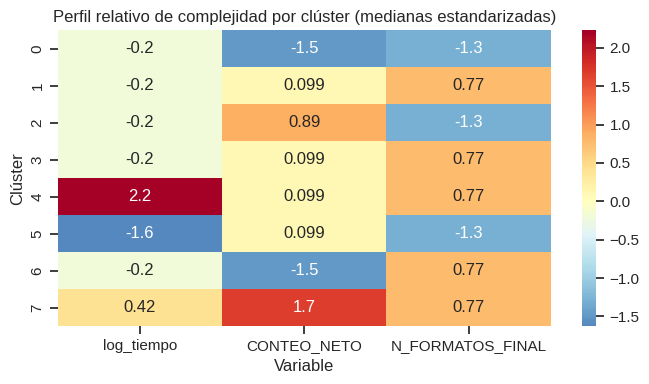

,log_tiempo,CONTEO_NETO,N_FORMATOS_FINAL
cluster,,,
0,-0.203734,-1.477994,-1.290994
1,-0.203734,0.098533,0.774597
2,-0.203734,0.886796,-1.290994
3,-0.203734,0.098533,0.774597
4,2.228353,0.098533,0.774597
5,-1.628374,0.098533,-1.290994
6,-0.203734,-1.477994,0.774597
7,0.418693,1.675060,0.774597


In [13]:
# Heatmap de perfil relativo (z-score de medianas)
meds = df.groupby('cluster')[['log_tiempo','CONTEO_NETO','N_FORMATOS_FINAL']].median()
meds_z = (meds - meds.mean()) / meds.std(ddof=0)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(meds_z, annot=True, cmap='RdYlBu_r', center=0, ax=ax)
ax.set_title('Perfil relativo de complejidad por clúster (medianas estandarizadas)')
ax.set_xlabel('Variable')
ax.set_ylabel('Clúster')
plt.tight_layout()
plt.show()

meds_z

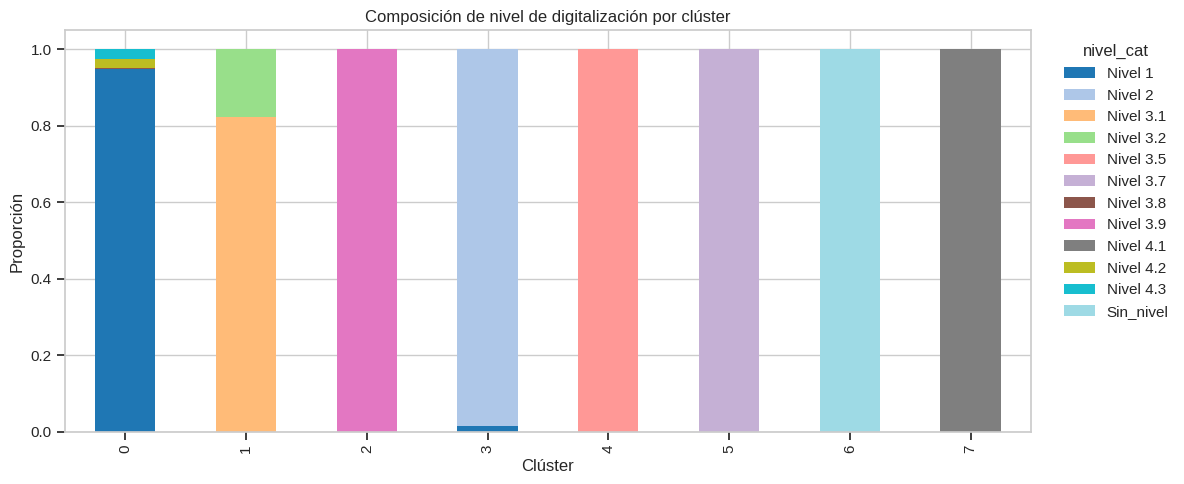

nivel_cat,Nivel 1,Nivel 2,Nivel 3.1,Nivel 3.2,Nivel 3.5,Nivel 3.7,Nivel 3.8,Nivel 3.9,Nivel 4.1,Nivel 4.2,Nivel 4.3,Sin_nivel
cluster,,,,,,,,,,,,
0,0.949,0.000,0.000,0.000,0.0,0.0,0.004,0.0,0.0,0.022,0.025,0.0
1,0.000,0.000,0.824,0.176,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0
2,0.000,0.000,0.000,0.000,0.0,0.0,0.000,1.0,0.0,0.000,0.000,0.0
3,0.014,0.986,0.000,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0
4,0.000,0.000,0.000,0.000,1.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0
5,0.000,0.000,0.000,0.000,0.0,1.0,0.000,0.0,0.0,0.000,0.000,0.0
6,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.000,1.0
7,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.0,1.0,0.000,0.000,0.0


In [14]:
# Composición de niveles de digitalización por clúster
comp = pd.crosstab(df['cluster'], df['nivel_cat'], normalize='index')

fig, ax = plt.subplots(figsize=(12, 5))
comp.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Composición de nivel de digitalización por clúster')
ax.set_xlabel('Clúster')
ax.set_ylabel('Proporción')
ax.legend(title='nivel_cat', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

comp.round(3)

## Interpretación sugerida

- El clúster con mayor `log_tiempo`, `CONTEO_NETO` y `N_FORMATOS_FINAL` puede interpretarse como **mayor complejidad operativa**.
- El clúster con menores medianas en esas tres variables puede interpretarse como **menor complejidad operativa**.
- La distribución de `nivel_cat` por clúster ayuda a verificar si la digitalización acompaña (o no) la complejidad observada.

Siguiente paso recomendado:
1. Mapear clústeres a etiquetas preliminares (`Baja`, `Media`, `Alta`).
2. Validar 20-30 casos con experto de dominio.
3. Pasar a modelo supervisado con esas etiquetas validadas.


In [15]:
# Exportar resultados para trazabilidad
out = Path.cwd() / 'outputs'
out.mkdir(exist_ok=True)

k_eval.to_csv(out / 'clustering_k_evaluation.csv', index=False)
cluster_profile.to_csv(out / 'clustering_cluster_profile.csv', index=False)
df[['Idtram','Tramite','cluster','log_tiempo','CONTEO_NETO','N_FORMATOS_FINAL','nivel_cat']].to_csv(
    out / 'clustering_assignments.csv', index=False
)

print('Archivos generados:')
for p in sorted(out.glob('clustering_*')):
    print('-', p.name)

Archivos generados:
- clustering_assignments.csv
- clustering_cluster_profile.csv
- clustering_k_evaluation.csv
